In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

### read data from file

In [2]:
train= pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

### Data Inspection

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.shape

(1460, 81)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
test.shape

(1459, 80)

In [7]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [8]:
y = train['SalePrice']
train = train.drop('SalePrice', axis=1)

In [9]:
df = pd.concat([train,test], ignore_index=True)

In [10]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


### Analyzing sale price

In [11]:
print(' The cheapest house is: ${:,.0f} and the most expensive is: ${:,.0f}'.format(y.min(), y.max()))
print(' The average of SalePrice is ${:,.0f} and the median is: ${:,.0f}'.format(y.mean(), y.median()))

 The cheapest house is: $34,900 and the most expensive is: $755,000
 The average of SalePrice is $180,921 and the median is: $163,000


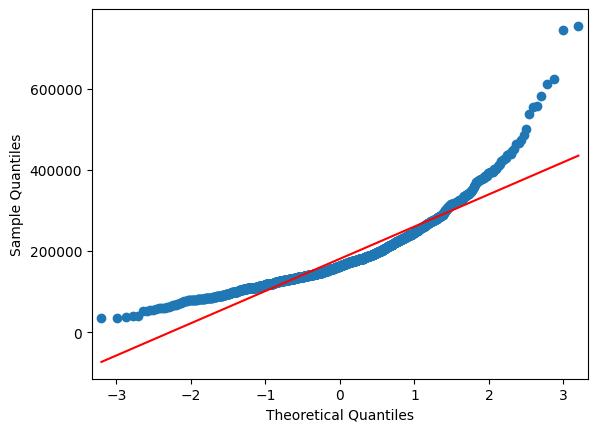

In [12]:
# QQ plot
qqplot_lm = sm.qqplot(y, line='s')
plt.show()

<Axes: xlabel='SalePrice', ylabel='Probability'>

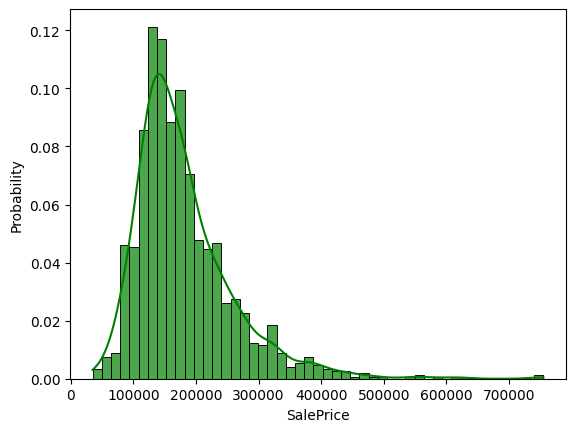

In [13]:
sns.histplot(y, stat= 'probability', kde= True, alpha= 0.7, color='green')

In [14]:
#The Data is Right-skewed so we use logy instead of y

In [15]:
log_y = np.log(y)

<Axes: xlabel='SalePrice', ylabel='Probability'>

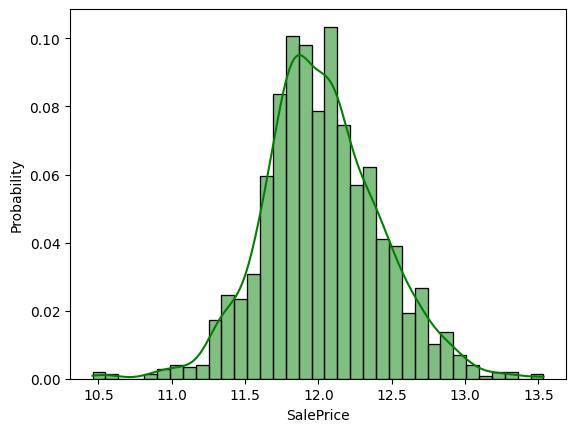

In [16]:
sns.histplot(log_y , stat= 'probability', kde= True, color='green')

### First I examine the relation between some ifluentioal parameters and SalePrice

C:\Users\AlMahdi\AppData\Local\Temp\ipykernel_6888\3242366201.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train['OverallQual'], y= y, palette = 'Set2')


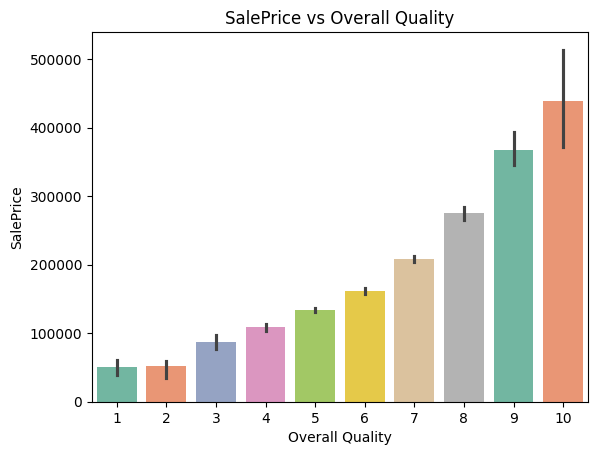

In [17]:
sns.barplot(x=train['OverallQual'], y= y, palette = 'Set2')
plt.title('SalePrice vs Overall Quality')
plt.xlabel('Overall Quality');

#### SalePrice is directly related to OverallQualiy

C:\Users\AlMahdi\AppData\Local\Temp\ipykernel_6888\3194152781.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train['OverallCond'], y= y, palette = 'Set2')


Text(0.5, 0, 'Overall Condition')

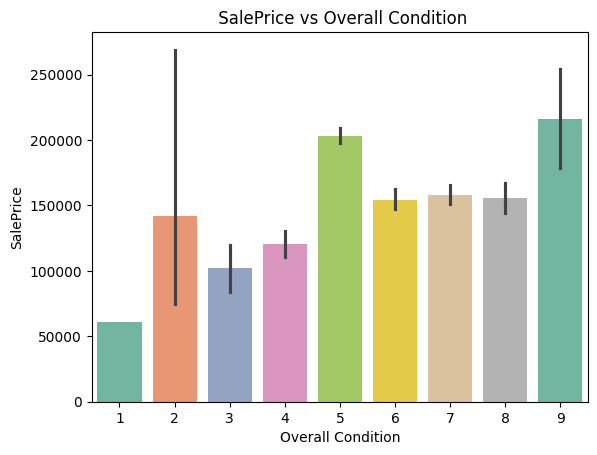

In [18]:
sns.barplot(x=train['OverallCond'], y= y, palette = 'Set2')
plt.title(' SalePrice vs Overall Condition')
plt.xlabel('Overall Condition')

Text(0.5, 1.0, 'SalePrice vs LotArea')

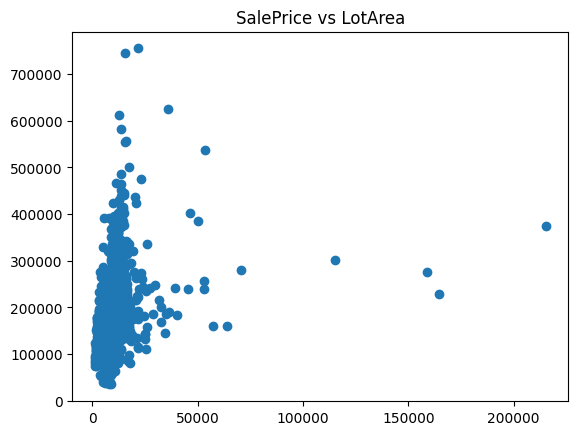

In [19]:
plt.scatter(x= train['LotArea'] , y= y)
plt.title('SalePrice vs LotArea')

In [20]:
df['LotArea'].mean()

10168.11408016444

In [21]:
train['LotArea'].mean()

10516.828082191782

In [22]:
numeric_features = ['LotFrontage', 'LotArea','YearBuilt','YearRemodAdd','MasVnrArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF',
                    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF','LowQualFinSF','GrLivArea','GarageYrBlt','GarageArea','WoodDeckSF','OpenPorchSF',
                    'EnclosedPorch','3SsnPorch','ScreenPorch','PoolArea','MiscVal','MoSold','YrSold']

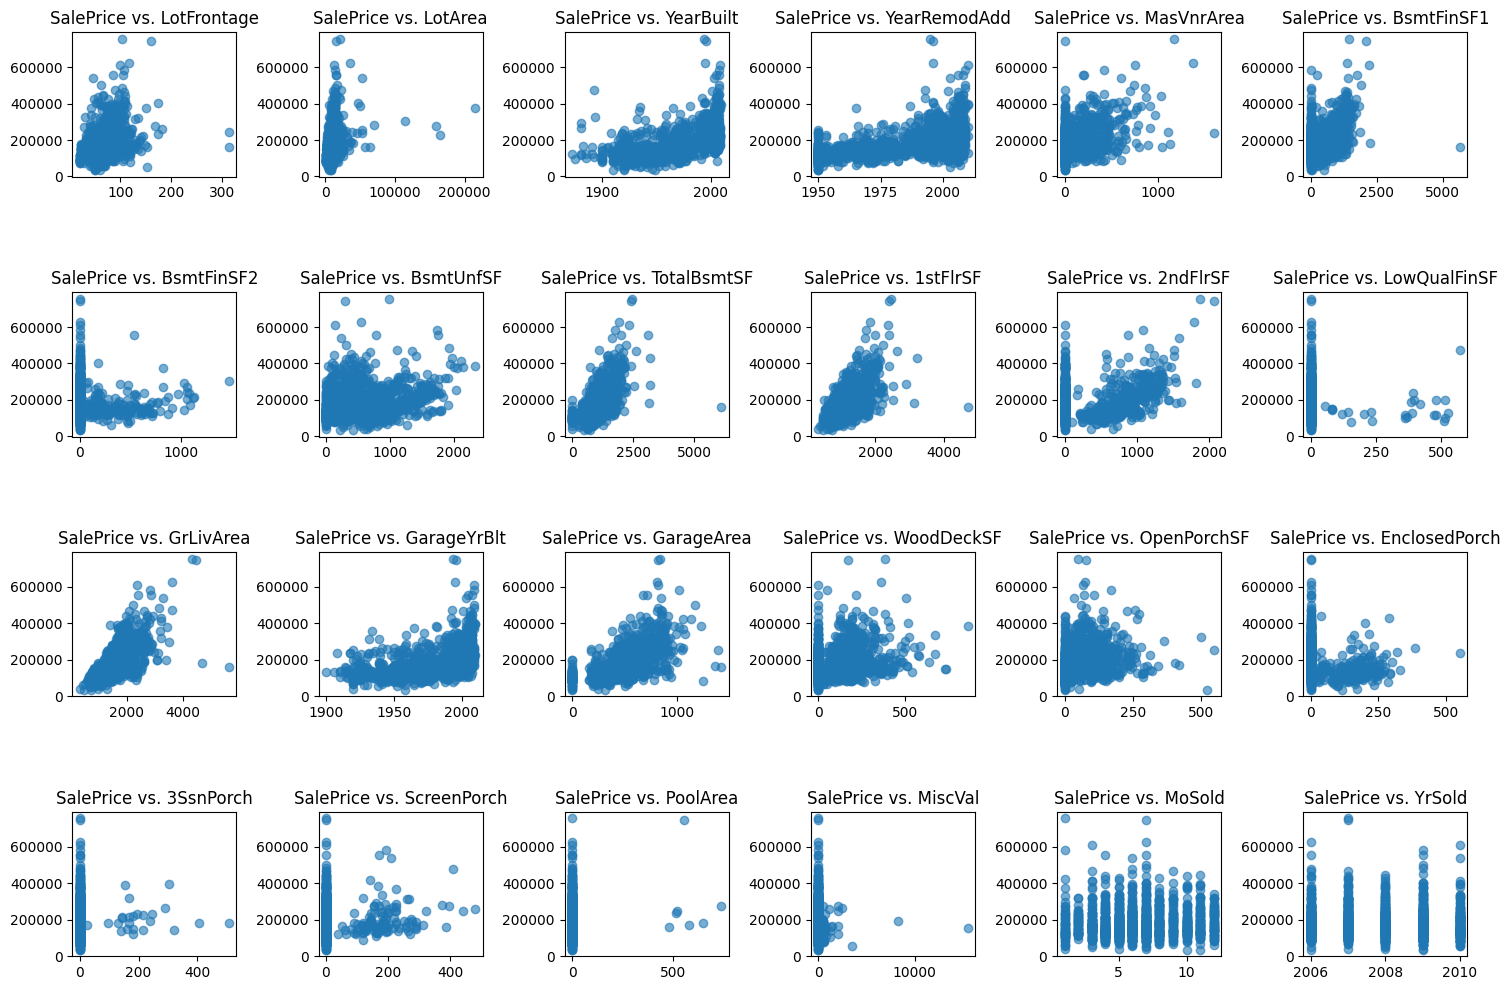

In [23]:
plot = plt.figure(figsize= (18,12))
plot.subplots_adjust(hspace=0.8, wspace=0.5)
for i in range(1, len(numeric_features)+1):
    a = plot.add_subplot(4,6,i)
    a.scatter(train[numeric_features[i-1]],  y , alpha=0.6)
    a.title.set_text('SalePrice vs. '+ numeric_features[i-1])

In [24]:
## based on these plots the most important features that have a large effect on SalePrice are : GrLivArea, TotalBsmtSF, 1stFlrSF,GarageArea,YearBuilt,
## YearRemodAdd

In [25]:
## some parameters that do not show obvious trend with SalePrice or more of them are zero can be neglected such as  
##'PoolArea','MiscVal','LowQualFinSF','3SsnPorch','ScreenPorch','MoSold','YrSold','EnclosedPorch','BsmtFinSF2'

In [26]:
## other features have moderate effect and should be manipulated before use

In [27]:
corr_train = pd.concat([train.loc[:,numeric_features],y.rename('SalePrice')],axis=1).corr(method="pearson")
round(corr_train,2)

,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
LotFrontage,1.00,0.43,0.12,0.09,0.19,0.23,0.05,0.13,0.39,0.46,...,0.09,0.15,0.01,0.07,0.04,0.21,0.00,0.01,0.01,0.35
LotArea,0.43,1.00,0.01,0.01,0.10,0.21,0.11,-0.00,0.26,0.30,...,0.17,0.08,-0.02,0.02,0.04,0.08,0.04,0.00,-0.01,0.26
YearBuilt,0.12,0.01,1.00,0.59,0.32,0.25,-0.05,0.15,0.39,0.28,...,0.22,0.19,-0.39,0.03,-0.05,0.00,-0.03,0.01,-0.01,0.52
YearRemodAdd,0.09,0.01,0.59,1.00,0.18,0.13,-0.07,0.18,0.29,0.24,...,0.21,0.23,-0.19,0.05,-0.04,0.01,-0.01,0.02,0.04,0.51
MasVnrArea,0.19,0.10,0.32,0.18,1.00,0.26,-0.07,0.11,0.36,0.34,...,0.16,0.13,-0.11,0.02,0.06,0.01,-0.03,-0.01,-0.01,0.48
BsmtFinSF1,0.23,0.21,0.25,0.13,0.26,1.00,-0.05,-0.50,0.52,0.45,...,0.20,0.11,-0.10,0.03,0.06,0.14,0.00,-0.02,0.01,0.39
BsmtFinSF2,0.05,0.11,-0.05,-0.07,-0.07,-0.05,1.00,-0.21,0.10,0.10,...,0.07,0.00,0.04,-0.03,0.09,0.04,0.00,-0.02,0.03,-0.01
BsmtUnfSF,0.13,-0.00,0.15,0.18,0.11,-0.50,-0.21,1.00,0.42,0.32,...,-0.01,0.13,-0.00,0.02,-0.01,-0.04,-0.02,0.03,-0.04,0.21
TotalBsmtSF,0.39,0.26,0.39,0.29,0.36,0.52,0.10,0.42,1.00,0.82,...,0.23,0.25,-0.10,0.04,0.08,0.13,-0.02,0.01,-0.01,0.61
1stFlrSF,0.46,0.30,0.28,0.24,0.34,0.45,0.10,0.32,0.82,1.00,...,0.24,0.21,-0.07,0.06,0.09,0.13,-0.02,0.03,-0.01,0.61


<Axes: >

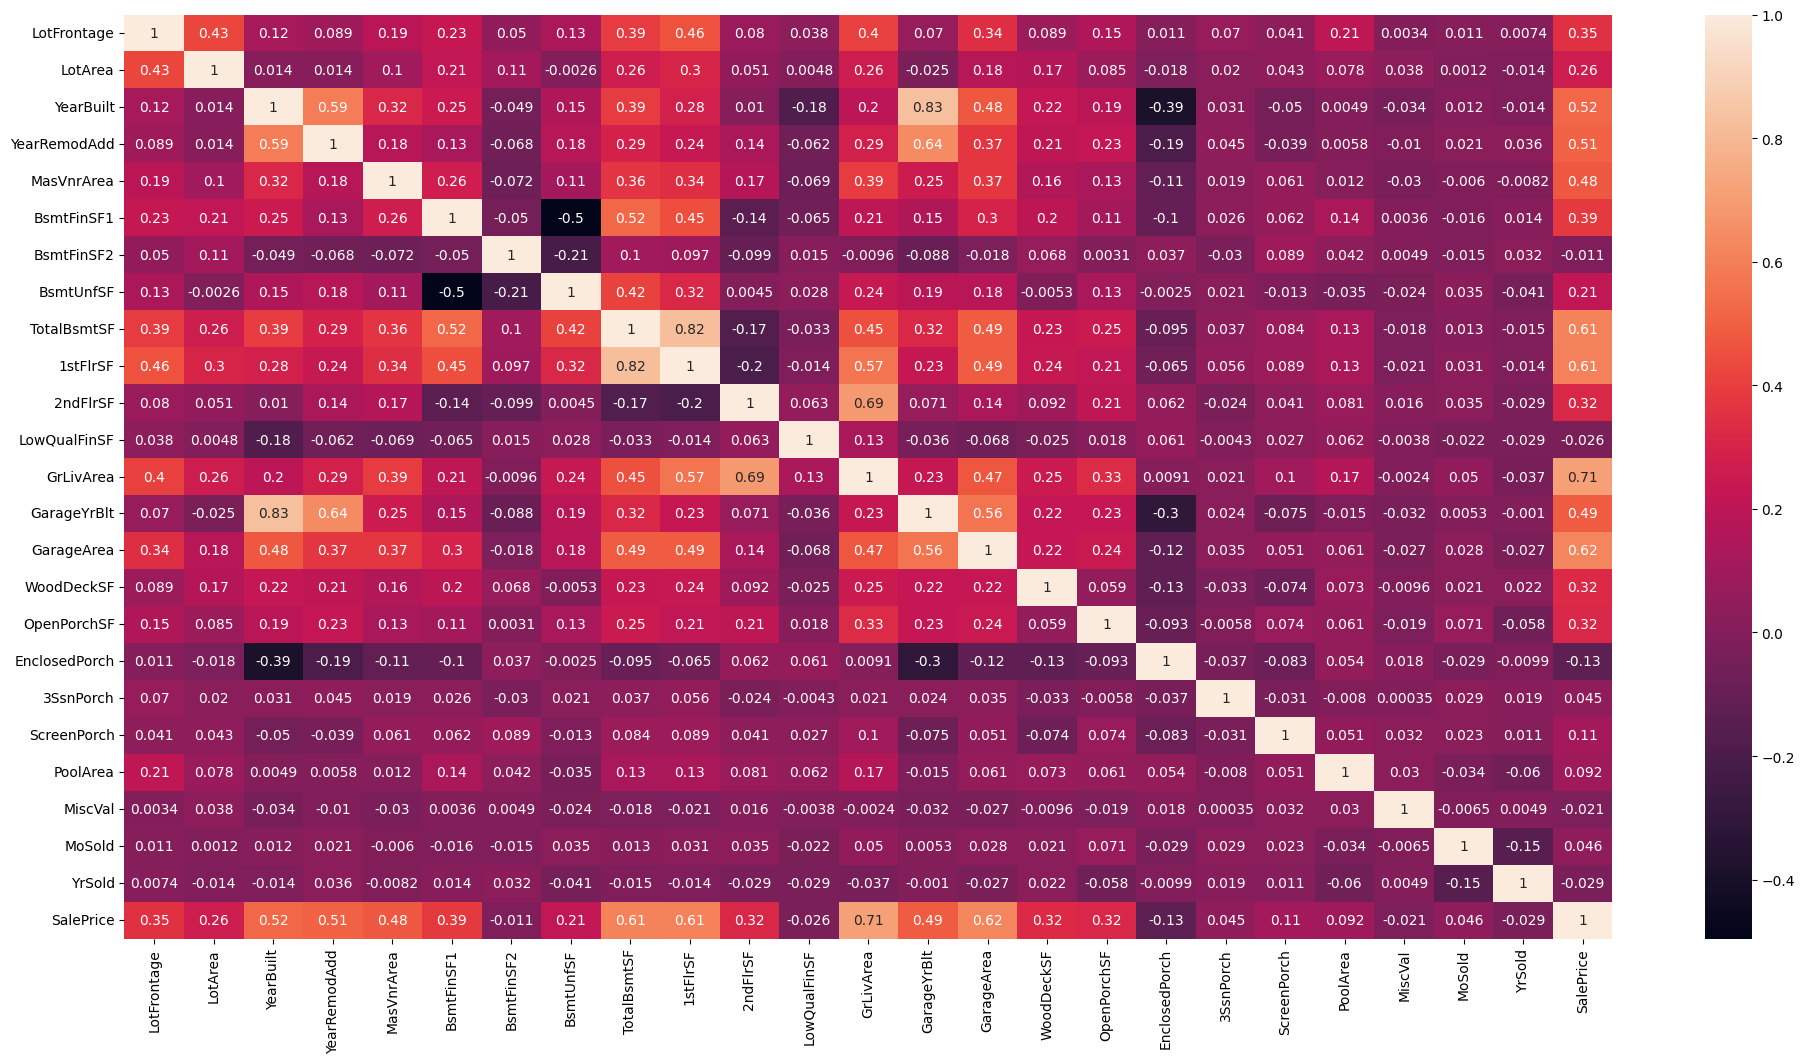

In [28]:
plt.figure(figsize=(24,12))
sns.heatmap(corr_train, annot=True)

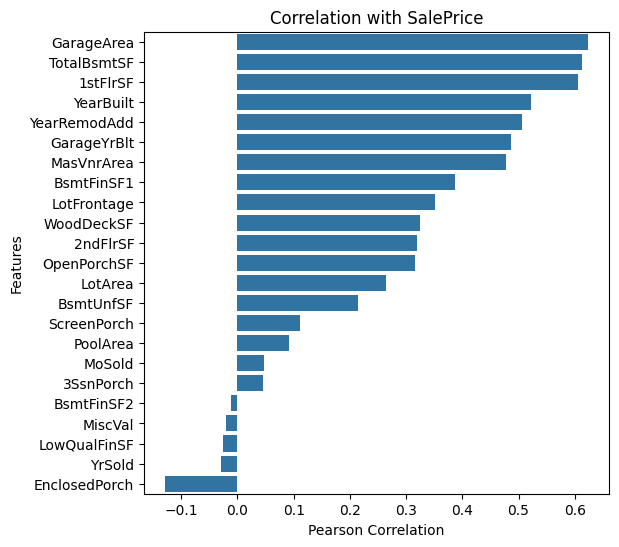

In [29]:
corr_table = corr_train.sort_values('SalePrice', ascending = False)
plt.figure(figsize =(6,6))
sns.barplot(x = corr_table.SalePrice[2:], y= corr_table.index[2:], orient='h')
plt.title('Correlation with SalePrice')
plt.xlabel('Pearson Correlation')
plt.ylabel('Features')
plt.show()

## Missing Values

In [30]:
pd.reset_option('max_rows')
pd.options.display.max_rows=None ## shows all the rows
df.isnull().sum()

Id                  0
MSSubClass          0
MSZoning            4
LotFrontage       486
LotArea             0
Street              0
Alley            2721
LotShape            0
LandContour         0
Utilities           2
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         1
Exterior2nd         1
MasVnrType       1766
MasVnrArea         23
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           81
BsmtCond           82
BsmtExposure       82
BsmtFinType1       79
BsmtFinSF1          1
BsmtFinType2       80
BsmtFinSF2          1
BsmtUnfSF           1
TotalBsmtSF         1
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [31]:
# Features that Na represents the absence of the corresponding feature rather than a missing value
## most of the features in next cells have more than 75 NaN

In [32]:
for col in ['Alley','MasVnrType','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','FireplaceQu','GarageType','GarageFinish',
            'GarageQual','GarageCond','PoolQC','Fence','MiscFeature']:
    df[col] = df[col].fillna('None')

In [33]:
# numerical Features that Na represents the absence of the corresponding feature rather than a missing value
# Except MasVnrArea and GarageYrBlt others have only one NaN

In [34]:
for col in ['MasVnrArea','GarageYrBlt','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','GarageCars','GarageArea']:
    df[col]= df[col].fillna(0)

In [35]:
## ['LotFrontage']: missing values do not mean lacking lot frontage, but rather they have not been recorded
## since LotFrontage depends on the neighborhood, and it's not completely random, we use its median on each neighborhood. 

In [36]:
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform( lambda x: x.fillna(x.median()))


In [37]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [38]:
df.isna().sum()

Id               0
MSSubClass       0
MSZoning         4
LotFrontage      0
LotArea          0
Street           0
Alley            0
LotShape         0
LandContour      0
Utilities        2
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      1
Exterior2nd      1
MasVnrType       0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     2
BsmtHalfBath     2
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr

In [39]:
df['MSZoning'].value_counts()

MSZoning
RL         2265
RM          460
FV          139
RH           26
C (all)      25
Name: count, dtype: int64

In [40]:
## ['MSZoning'] is similar to ['LotFrontage'] and it depends on neighborhood so I replace NaN with its mode based on neighborhood

In [41]:
df['MSZoning'] = df.groupby("Neighborhood")["MSZoning"].transform(lambda x:x.fillna(x.mode()[0]))

In [42]:
df['Utilities'].value_counts(dropna=False)

Utilities
AllPub    2916
NaN          2
NoSeWa       1
Name: count, dtype: int64

In [43]:
df['Utilities'] = df['Utilities'].fillna('AllPub')

In [44]:
df['Exterior1st'].value_counts()

Exterior1st
VinylSd    1025
MetalSd     450
HdBoard     442
Wd Sdng     411
Plywood     221
CemntBd     126
BrkFace      87
WdShing      56
AsbShng      44
Stucco       43
BrkComm       6
AsphShn       2
Stone         2
CBlock        2
ImStucc       1
Name: count, dtype: int64

In [45]:
for col in ['Exterior1st','Exterior2nd']:
    df[col]=df[col].fillna(df[col].mode()[0])

In [46]:
df['BsmtFullBath'] = df['BsmtFullBath'].fillna(0)
df['BsmtHalfBath'] = df['BsmtHalfBath'].fillna(0)

In [47]:
df['KitchenQual'].value_counts()

KitchenQual
TA    1492
Gd    1151
Ex     205
Fa      70
Name: count, dtype: int64

In [48]:
df['Functional'].value_counts()

Functional
Typ     2717
Min2      70
Min1      65
Mod       35
Maj1      19
Maj2       9
Sev        2
Name: count, dtype: int64

In [49]:
df['SaleType'].value_counts()

SaleType
WD       2525
New       239
COD        87
ConLD      26
CWD        12
ConLI       9
ConLw       8
Oth         7
Con         5
Name: count, dtype: int64

In [50]:
df['KitchenQual'] = df['KitchenQual'].fillna(df['KitchenQual'].mode()[0])

In [51]:
df['Functional'] = df['Functional'].fillna('Typ')

In [52]:
df['SaleType'] = df['SaleType'].fillna('WD')

In [53]:
df.isna().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
Alley            0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrType       0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr

In [54]:
# all missing values have been handled, for numerical coloumns with many missing values, we filled them using the median within their groups, 
# others were replaced with zero. For categorical columns,those with many NaN were filled with None, while coloumns with fewer NaN were filled using their mode 

In [55]:
categorical_features = list(df.select_dtypes(include= ['object']).columns.tolist())
categorical_features

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [56]:
## some variables are numeric but since they are not continuous and instead behave like categorical features, 
## we add them to the list above

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2919 non-null   object 
 3   LotFrontage    2919 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          2919 non-null   object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2919 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallC

In [58]:
categorical_features.extend(['MSSubClass','OverallQual','OverallCond','FullBath','HalfBath'
                              ,'BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd','Fireplaces','BsmtFullBath',
                             'BsmtHalfBath','GarageCars'])

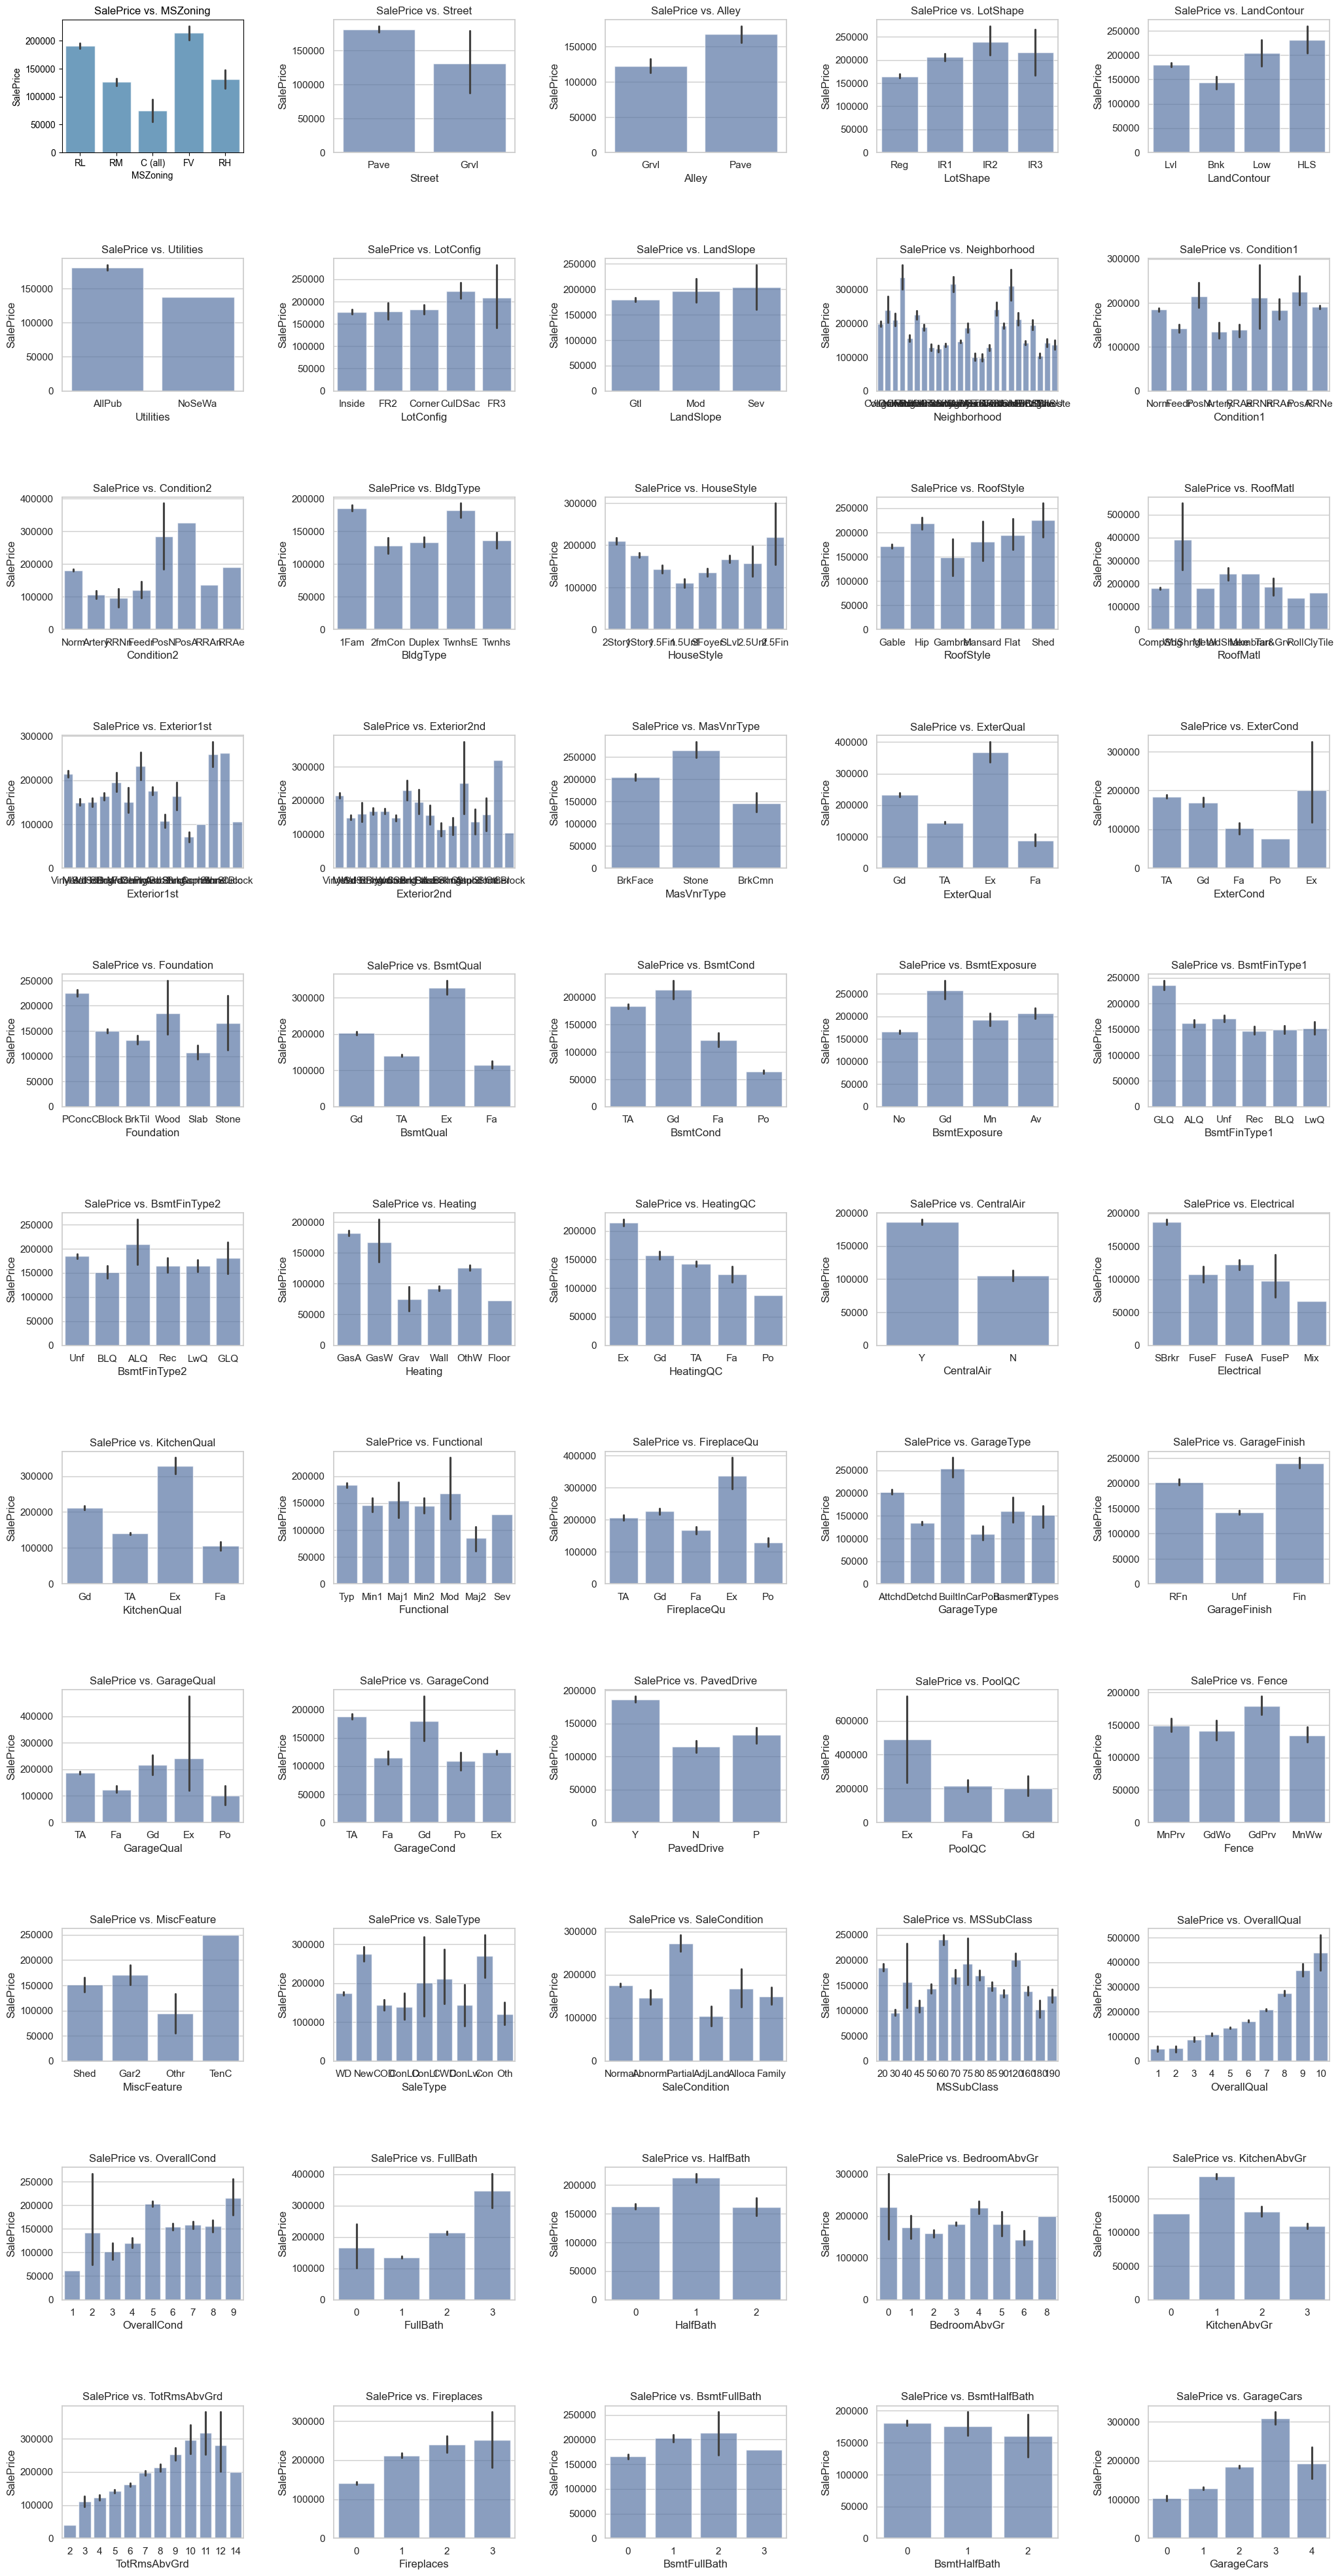

In [59]:
plot = plt.figure(figsize= (25,50))
plot.subplots_adjust(hspace=0.8, wspace=0.5)
for i in range(1, len(categorical_features)+1):
    a = plot.add_subplot(11,5,i)
    sns.set(style ='whitegrid', palette ='deep')
    sns.barplot(x= train[categorical_features[i-1]],  y=y , alpha=0.7)
    a.title.set_text('SalePrice vs. '+ categorical_features[i-1])

In [60]:
## we combine train and test data to preprocessing them, now for running models because the rows of y is equal to train
## we split df to train and test

In [61]:
df_categorical_encoded = pd.get_dummies(df, columns=categorical_features, drop_first= True)

In [62]:
df_categorical_encoded.dtypes.value_counts()

bool       298
int64       17
float64      8
Name: count, dtype: int64

In [63]:
df.shape

(2919, 80)

In [64]:
df_categorical_encoded.shape

(2919, 323)

In [65]:
df_categorical_encoded = df_categorical_encoded.drop("Id", axis=1)

In [66]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.set_output(transform = "pandas")
df_scaled= scaler.fit_transform(df_categorical_encoded)

In [67]:
train_l = df_scaled[:len(log_y)]

In [68]:
train_l.shape

(1460, 322)

In [69]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(train_l, log_y, test_size= 0.2, random_state=42)

### Building Prediction Models

## Model 1 : Linear Regression

In [70]:
X_train.shape

(1168, 322)

In [71]:
X_valid.shape

(292, 322)

In [72]:
X_train_sm = sm.add_constant(X_train)

In [73]:
y_train.head()

254     11.884489
1066    12.089539
638     11.350407
799     12.072541
380     11.751942
Name: SalePrice, dtype: float64

In [74]:
lm = sm.OLS(y_train, X_train_sm).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     57.39
Date:                Fri, 12 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:10:40   Log-Likelihood:                 1205.2
No. Observations:                1168   AIC:                            -1816.
Df Residuals:                     871   BIC:                            -312.7
Df Model:                         296                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
LotFrontage               0.0037      0.005      0.724      0.469      -0.006       0.014
LotArea                   0.0138      0.005      2.598      0.010       0.003       0.024
YearBuilt                 0.0567      0.013      4.265      0.000       0.031       0.083
YearRemodAdd              0.0233      0.006      3.775      0.000       0.011       0.035
MasVnrArea                0.0073      0.006      1.271      0.204      -0.004       0.019
BsmtFinSF1                0.0288      0.006      5.175      0.000       0.018       0.040
BsmtFinSF2                0.0089      0.007      1.351      0.177      -0.004       0.022
BsmtUnfSF                 0.0039      0.005      0.796      0.426      -0.006       0.013
TotalBsmtSF               0.0370      0.008      4.810      0.000       0.022       0.052
1stFlrSF                  0.0310      0.009      3.572      0.000       0.014       0.048
2ndFlrSF                  0.0495      0.010      5.184      0.000       0.031       0.068
LowQualFinSF              0.0061      0.005      1.155      0.249      -0.004       0.017
GrLivArea                 0.0665      0.007      9.254      0.000       0.052       0.081
GarageYrBlt              -0.0252      0.144     -0.176      0.861      -0.307       0.257
GarageArea                0.0318      0.009      3.510      0.000       0.014       0.050
WoodDeckSF                0.0110      0.004      2.881      0.004       0.004       0.019
OpenPorchSF               0.0024      0.004      0.598      0.550      -0.005       0.010
EnclosedPorch             0.0053      0.004      1.234      0.218      -0.003       0.014
3SsnPorch                 0.0061      0.003      2.304      0.021       0.001       0.011
ScreenPorch               0.0123      0.004      3.296      0.001       0.005       0.020
PoolArea                  0.1290      0.182      0.709      0.478      -0.228       0.486
MiscVal                  -0.0030      0.018     -0.172      0.864      -0.037       0.031
MoSold                   -0.0014      0.003     -0.413      0.680      -0.008       0.005
YrSold                   -0.0033      0.004     -0.935      0.350      -0.010       0.004
MSZoning_FV               0.0878      0.017      5.127      0.000       0.054       0.121
MSZoning_RH               0.0323      0.008      4.244      0.000       0.017       0.047
MSZoning_RL               0.1495      0.031      4.835      0.000       0.089       0.210
MSZoning_RM               0.1199      0.026      4.591      0.000       0.069       0.171
Street_Pave               0.0018      0.004      0.401      0.688      -0.007       0.011
Alley_None               -0.0044      0.006     -0.786      0.432      -0.015       0.007
Alley_Pave                0.0012      0.005      0.223      0.824      -0.009       0.012
LotShape_IR2           

#### check assumptions of Normality

<Axes: ylabel='Probability'>

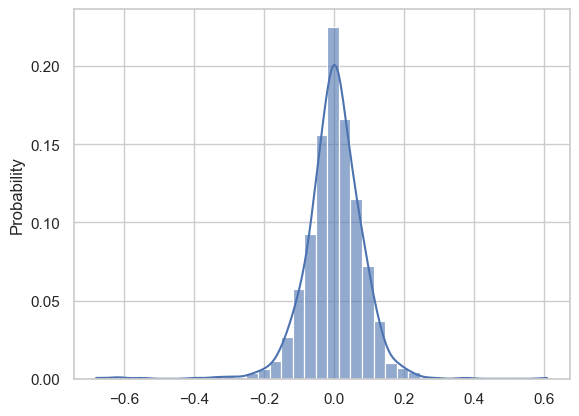

In [75]:
## histogram of residuals
sns.histplot(lm.resid, stat= "probability", kde=True, alpha= 0.6,
             bins =np.linspace(min(lm.resid), max(lm.resid), 40))

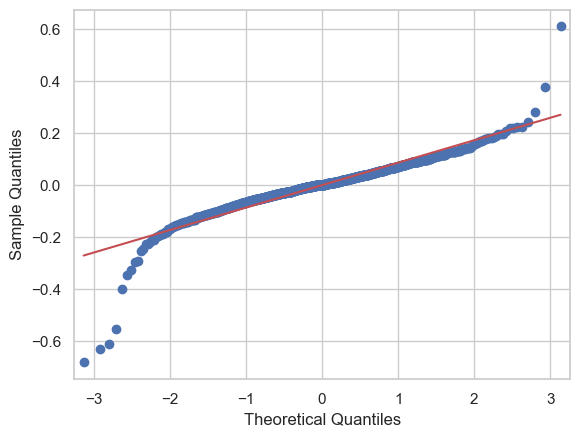

In [76]:
## QQ-plot
qqplot_lm = sm.qqplot(lm.resid, line='s')
plt.show()

In [77]:
## Residual diagnostics showed that the assumption of linear regression were somehow acceptable, the residual distribution was approximately normal,
## while QQ-plot analysis revealed mild deviations in the tail and several potential outliers, residuals are randomly scattered around zero with no 
## strong evidence of nonlinearity or severe heteroscedasticity

In [78]:
#Test for Skewness and Kurtosis
#Good for sample size > 25

#Jarque-Bera Test (Skewness = 0 ?)
#H0: the data is normally distributed
#p-value < 0.05 reject normality assumption

#Omnibus K-squared normality test
#The Omnibus test combines the random variables for Skewness and Kurtosis into a single test statistic
#H0: the data is normally distributed
#p-value < 0.05 reject normality assumption

In [79]:
## Both Probabilities are zero so H0(normality assumption) is rejected

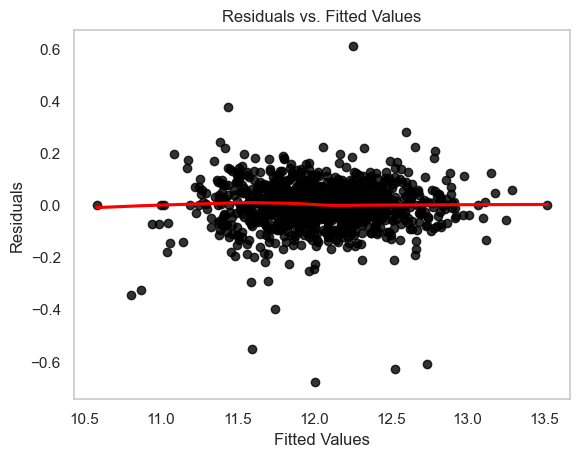

In [80]:
#Residuals vs. Fitted Values
sns.regplot(x = lm.fittedvalues, y = lm.resid, lowess = True, 
                       scatter_kws = {"color": "black"}, line_kws = {"color": "red"})
plt.xlabel('Fitted Values', fontsize = 12)
plt.ylabel('Residuals', fontsize = 12)
plt.title('Residuals vs. Fitted Values', fontsize = 12)
plt.grid()

In [81]:
#Check Multicollinearity
#Import library for VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calc_vif(X):
    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return(vif)

calc_vif(X_train.iloc[:, 1:])
#If VIF > 10 then multicollinearity is high

C:\Users\AlMahdi\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\Users\AlMahdi\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,variables,VIF
0,LotArea,6.067285
1,YearBuilt,21.206351
2,YearRemodAdd,4.389100
3,MasVnrArea,3.604320
4,BsmtFinSF1,inf
5,BsmtFinSF2,inf
6,BsmtUnfSF,inf
7,TotalBsmtSF,inf
8,1stFlrSF,inf
9,2ndFlrSF,inf


In [82]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [83]:
y_pred = lr.predict(X_valid)

In [84]:
abs_err_lr = abs(y_valid - y_pred)

In [85]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_percentage_error
r2_lr = r2_score(y_valid,y_pred)
RMSE_lr = np.sqrt(mean_squared_error(y_valid,y_pred))

In [86]:
#MAPE (Mean Absolute Percentage Error) is calculated due to the skewed distribution of house prices and it is better to 
#calculate this metric on non_log_transformed values to ensure meaningful interpretation.
y_pred_real = np.exp(y_pred)
y_valid_real = np.exp(y_valid)
MAPE= mean_absolute_percentage_error(y_valid_real,y_pred_real)*100  

In [87]:
from scipy.stats import iqr
model_comp = pd.DataFrame({' r2':r2_lr,
                           'RMSE' :RMSE_lr,
                           'MAPE' :MAPE,
                           'Mean of AbsErrors':abs_err_lr.mean(),
                           'Median of AbsErrors': abs_err_lr.median(),
                           'SD of AbsErrors': abs_err_lr.std(),
                           'IQR of AbsErrors': iqr(abs_err_lr),
                           'Min of AbsErrors': abs_err_lr.min(),
                           'Max of AbsErrors': abs_err_lr.max()},index =['Linear Regression'])
model_comp.round(3)

,r2,RMSE,MAPE,Mean of AbsErrors,Median of AbsErrors,SD of AbsErrors,IQR of AbsErrors,Min of AbsErrors,Max of AbsErrors
Linear Regression,0.818,0.185,9.18,0.095,0.059,0.158,0.098,0.0,2.279


C:\Users\AlMahdi\AppData\Local\Temp\ipykernel_6888\3255360313.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.1, 0.1, 0.1, 1)). The keyword argument will take precedence.
  plt.plot(xp,xp,'k',alpha=0.9, linewidth=2, color='red')


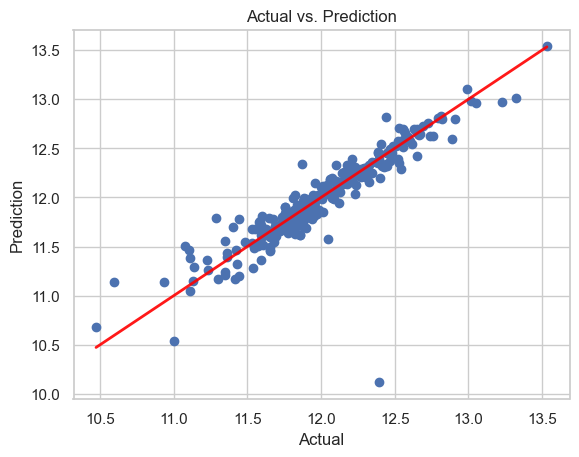

In [88]:
# Actual vs. Prediction
plt.scatter( x=y_valid, y=y_pred)
plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs. Prediction')

#Add 45 degree line
xp = np.linspace(y_valid.min(), y_valid.max(),100)
plt.plot(xp,xp,'k',alpha=0.9, linewidth=2, color='red')

#### Inspect top coefficients:

In [89]:
coef = pd.Series(lr.coef_, index=train_l.columns)
coef.sort_values(key=abs, ascending =False).head(10)

RoofMatl_CompShg    0.248458
RoofMatl_Tar&Grv    0.177200
MSZoning_RL         0.149456
TotRmsAbvGrd_6      0.132173
PoolArea            0.129049
OverallQual_7       0.123506
TotRmsAbvGrd_7      0.122850
MSZoning_RM         0.119935
OverallQual_6       0.119611
OverallQual_8       0.117723
dtype: float64

## Model 2 : Ridge Regression

In [90]:
# Ridge regression and using k-fold Cross Validation to choose the best Model
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
lambda_grid = 10**np.linspace(3,-3,100)
cv_errors = np.zeros(shape=len(lambda_grid))
for i in range(len(lambda_grid)):
    ridgereg = Ridge(alpha=lambda_grid[i])
    scores = cross_val_score(estimator=ridgereg,X= X_train, y=y_train,
                             scoring= 'neg_root_mean_squared_error',
                             cv=5 , n_jobs=-1)
    cv_errors[i]=scores.mean()

In [91]:
cv_errors

array([-0.15203204, -0.15135914, -0.15093701, -0.15074545, -0.15076474,
       -0.1509756 , -0.15135914, -0.15189692, -0.15257101, -0.15336416,
       -0.15425986, -0.15524248, -0.15629738, -0.15741091, -0.15857053,
       -0.15976474, -0.16098306, -0.16221607, -0.16345529, -0.16469323,
       -0.16592337, -0.16714017, -0.16833908, -0.16951659, -0.17067018,
       -0.1717983 , -0.1729003 , -0.1739762 , -0.17502657, -0.17605218,
       -0.17705378, -0.17803179, -0.17898607, -0.17991576, -0.18081919,
       -0.1816939 , -0.18253679, -0.18334433, -0.18411281, -0.18483864,
       -0.18551858, -0.18615001, -0.18673108, -0.18726073, -0.18773882,
       -0.18816596, -0.18854353, -0.18887349, -0.1891583 , -0.1894008 ,
       -0.18960411, -0.18977158, -0.18990674, -0.19001337, -0.19009545,
       -0.19015728, -0.19020349, -0.19023909, -0.1902695 , -0.19030049,
       -0.19033807, -0.19038832, -0.19045718, -0.19055014, -0.19067194,
       -0.19082622, -0.19101531, -0.19124002, -0.19149955, -0.19

In [92]:
best_lambda = lambda_grid[np.argmax(cv_errors)]
best_lambda

657.9332246575682

In [93]:
ridgereg = Ridge(alpha=best_lambda)
ridge_reg = ridgereg.fit(X_train, y_train)
ridge_reg.coef_

array([ 2.97136091e-03,  1.09260802e-02,  1.31406792e-02,  1.82438374e-02,
        8.71024017e-03,  1.26843779e-02,  4.53345224e-03,  3.04208165e-03,
        1.78711161e-02,  2.38606139e-02,  1.35588114e-02,  2.56205518e-03,
        3.02213653e-02,  5.87387576e-03,  1.76828001e-02,  1.18087718e-02,
        5.48988245e-03,  4.42877889e-04,  5.40554838e-03,  1.01737628e-02,
        4.41312821e-03,  1.33781212e-03,  1.54955545e-03, -9.36572395e-04,
        6.33596893e-03,  7.51569140e-04,  7.07018500e-03, -7.94123305e-03,
        1.34860876e-03,  5.95424376e-04,  4.06721086e-03,  4.77720925e-03,
       -4.75577738e-03, -3.21100096e-03,  7.08627858e-03, -1.80303452e-03,
        4.04899822e-03, -3.69977764e-03,  8.90266615e-03, -3.80136474e-03,
       -1.82998236e-03, -2.92467728e-03,  7.79084695e-04, -1.62418195e-03,
       -8.30063595e-04, -4.83091615e-03,  1.77351404e-03,  5.55382106e-03,
       -4.83658443e-04,  1.37853735e-02, -1.01339587e-02, -4.54058179e-03,
       -5.28138478e-03, -

In [94]:
#Prediction
pred_ridge = ridge_reg.predict(X_valid)

In [95]:
abs_err_ridge = abs(y_valid - pred_ridge)

In [96]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_percentage_error
r2_ridge = r2_score(y_valid,pred_ridge)
RMSE_ridge = np.sqrt(mean_squared_error(y_valid,pred_ridge))

In [97]:
pred_ridge_real = np.exp(pred_ridge)
y_valid_real = np.exp(y_valid)
MAPE_ridge = mean_absolute_percentage_error(y_valid_real,pred_ridge_real)*100  

In [98]:
from scipy.stats import iqr
Ridge_row = pd.DataFrame({' r2':r2_ridge,
                           'RMSE' : RMSE_ridge,
                           'MAPE' : MAPE_ridge,
                           'Mean of AbsErrors': abs_err_ridge.mean(),
                           'Median of AbsErrors': abs_err_ridge.median(),
                           'SD of AbsErrors': abs_err_ridge.std(),
                           'IQR of AbsErrors': iqr(abs_err_ridge),
                           'Min of AbsErrors': abs_err_ridge.min(),
                           'Max of AbsErrors': abs_err_ridge.max()},index =['Ridge Regression'])
model_comp = pd.concat([model_comp, Ridge_row])
model_comp.round(3)

,r2,RMSE,MAPE,Mean of AbsErrors,Median of AbsErrors,SD of AbsErrors,IQR of AbsErrors,Min of AbsErrors,Max of AbsErrors
Linear Regression,0.818,0.185,9.180,0.095,0.059,0.158,0.098,0.0,2.279
Ridge Regression,0.875,0.153,10.388,0.098,0.059,0.117,0.099,0.0,0.928


C:\Users\AlMahdi\AppData\Local\Temp\ipykernel_6888\435281733.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.1, 0.1, 0.1, 1)). The keyword argument will take precedence.
  plt.plot(xp,xp,'k',alpha=0.9, linewidth=2, color='red')


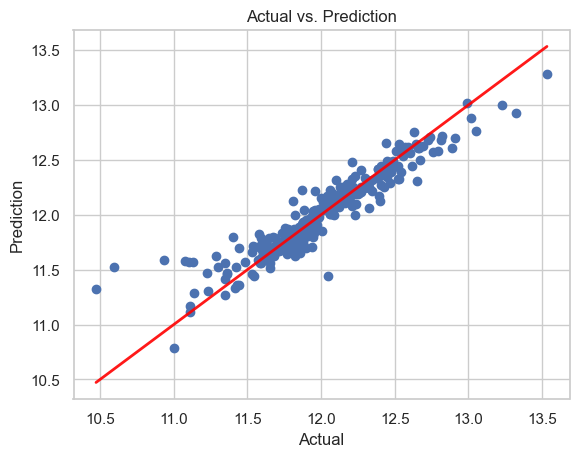

In [99]:
# Actual vs. Prediction
plt.scatter( x=y_valid, y=pred_ridge )
plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs. Prediction')

#Add 45 degree line
xp = np.linspace(y_valid.min(), y_valid.max(),100)
plt.plot(xp,xp,'k',alpha=0.9, linewidth=2, color='red')

## Model 3 : Lasso Regression

In [100]:
# Lasso regression and using k-fold Cross Validation to choose the best Model
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score
cv_errors = np.zeros(shape=len(lambda_grid))
for i in range(len(lambda_grid)):
    lassoreg = Lasso(alpha=lambda_grid[i])
    scores = cross_val_score(estimator=lassoreg,X= X_train, y=y_train,
                             scoring= 'neg_root_mean_squared_error',
                             cv=5 , n_jobs=-1)
    cv_errors[i]=scores.mean()

In [101]:
cv_errors

array([-0.39009555, -0.39009555, -0.39009555, -0.39009555, -0.39009555,
       -0.39009555, -0.39009555, -0.39009555, -0.39009555, -0.39009555,
       -0.39009555, -0.39009555, -0.39009555, -0.39009555, -0.39009555,
       -0.39009555, -0.39009555, -0.39009555, -0.39009555, -0.39009555,
       -0.39009555, -0.39009555, -0.39009555, -0.39009555, -0.39009555,
       -0.39009555, -0.39009555, -0.39009555, -0.39009555, -0.39009555,
       -0.39009555, -0.39009555, -0.39009555, -0.39009555, -0.39009555,
       -0.39009555, -0.39009555, -0.39009555, -0.39009555, -0.39009555,
       -0.39009555, -0.39009555, -0.39009555, -0.39009555, -0.39009555,
       -0.39009555, -0.39009555, -0.39009555, -0.39009555, -0.39009555,
       -0.39009555, -0.39009555, -0.39009555, -0.39009555, -0.39009555,
       -0.39009555, -0.39009555, -0.39009555, -0.39009555, -0.38190467,
       -0.35976162, -0.3340529 , -0.30742478, -0.28509699, -0.2659557 ,
       -0.2495347 , -0.23544971, -0.22367373, -0.21424554, -0.20

In [102]:
best_lamda = lambda_grid[np.argmax(cv_errors)]
best_lamda

0.007054802310718645

In [103]:
# Best model coefs:
lassoreg =Lasso(alpha = best_lamda)
lasso_reg = lassoreg.fit(X_train, y_train)
lasso_reg.coef_

array([ 0.        ,  0.01000386,  0.03244993,  0.03445624,  0.        ,
        0.00675384,  0.        , -0.        ,  0.02844443,  0.        ,
        0.        , -0.        ,  0.12703783,  0.01422618,  0.03317888,
        0.01047352,  0.        , -0.        ,  0.00075803,  0.00899577,
        0.        ,  0.        ,  0.        , -0.        ,  0.        ,
       -0.        ,  0.        , -0.01551527,  0.        , -0.        ,
        0.        ,  0.00152189, -0.00265255, -0.        ,  0.        ,
       -0.        ,  0.        , -0.        ,  0.0095495 , -0.        ,
       -0.        , -0.        ,  0.        , -0.        , -0.        ,
       -0.        ,  0.00013245,  0.00160658,  0.        ,  0.01652229,
       -0.00489492, -0.        , -0.        , -0.00959458, -0.        ,
       -0.        ,  0.        , -0.        ,  0.        ,  0.01544885,
       -0.        , -0.        , -0.        , -0.        ,  0.00801042,
        0.00907427,  0.        ,  0.00034996, -0.        ,  0.01

In [104]:
# prediction
pred_lasso = lasso_reg.predict(X_valid)

In [105]:
abs_err_lasso = abs(y_valid - pred_lasso)

In [106]:
r2_lasso = r2_score(y_valid,pred_lasso)
RMSE_lasso = np.sqrt(mean_squared_error(y_valid,pred_lasso))

In [107]:
pred_lasso_real = np.exp(pred_lasso)
y_valid_real = np.exp(y_valid)
MAPE_lasso = mean_absolute_percentage_error(y_valid_real,pred_lasso_real)*100 

In [108]:
Lasso_row = pd.DataFrame({' r2':r2_lasso,
                           'RMSE':RMSE_lasso,
                           'MAPE': MAPE_lasso,
                           'Mean of AbsErrors':abs_err_lasso.mean(),
                           'Median of AbsErrors': abs_err_lasso.median(),
                           'SD of AbsErrors': abs_err_lasso.std(),
                           'IQR of AbsErrors': iqr(abs_err_lasso),
                           'Min of AbsErrors': abs_err_lasso.min(),
                           'Max of AbsErrors': abs_err_lasso.max()},index =['lasso Regression'])
model_comp = pd.concat([model_comp, Lasso_row])
model_comp.round(3)

,r2,RMSE,MAPE,Mean of AbsErrors,Median of AbsErrors,SD of AbsErrors,IQR of AbsErrors,Min of AbsErrors,Max of AbsErrors
Linear Regression,0.818,0.185,9.180,0.095,0.059,0.158,0.098,0.0,2.279
Ridge Regression,0.875,0.153,10.388,0.098,0.059,0.117,0.099,0.0,0.928
lasso Regression,0.866,0.158,10.576,0.100,0.064,0.123,0.080,0.0,0.940


C:\Users\AlMahdi\AppData\Local\Temp\ipykernel_6888\990277626.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.1, 0.1, 0.1, 1)). The keyword argument will take precedence.
  plt.plot(xp,xp,'k',alpha=0.9, linewidth=2, color='red')


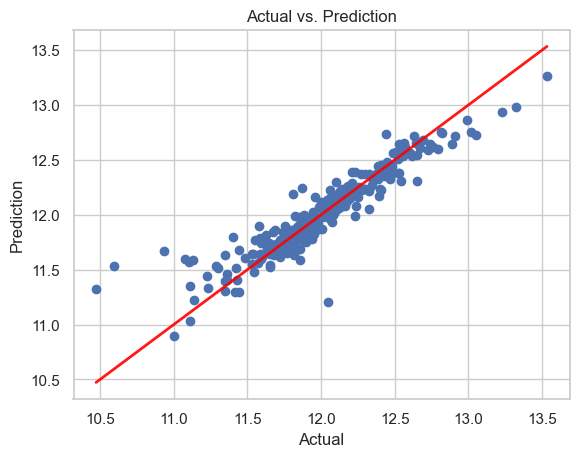

In [109]:
# Actual vs. Prediction
plt.scatter( x=y_valid, y=pred_lasso )
plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs. Prediction')

#Add 45 degree line
xp = np.linspace(y_valid.min(), y_valid.max(),100)
plt.plot(xp,xp,'k',alpha=0.9, linewidth=2, color='red')

## Model 4: Decision Tree

In [110]:
from sklearn.tree import DecisionTreeRegressor

In [111]:
# k-fold Cross Validation to choose Hyper-parameters
# create Hyper-parameters grid
import itertools
max_depth = range(4,10)
min_samples_leaf = np.arange(15,50, step=5)
ccp_alpha = [0.0001,0.001,0.01]
grid = list(itertools.product(max_depth,min_samples_leaf, ccp_alpha))
grid = pd.DataFrame(data=grid, index=range(1,127), columns= ['max_depth','min_samples_leaf','ccp_alpha'])
grid

,max_depth,min_samples_leaf,ccp_alpha
1,4,15,0.0001
2,4,15,0.0010
3,4,15,0.0100
4,4,20,0.0001
5,4,20,0.0010
6,4,20,0.0100
7,4,25,0.0001
8,4,25,0.0010
9,4,25,0.0100
10,4,30,0.0001


In [112]:
# k-fold Cross Validation to choose the Best Model
from sklearn.model_selection import cross_val_score
cv_errors = np.zeros(shape = grid.shape[0])
for i in range(grid.shape[0]):
    reg_tree = DecisionTreeRegressor(max_depth= grid.iloc[i,0], min_samples_leaf= grid.iloc[i,1], ccp_alpha= grid.iloc[i,2])
    scores = cross_val_score(estimator = reg_tree, X = X_train, y= y_train, scoring = 'neg_root_mean_squared_error', cv=5, n_jobs=-1)
    cv_errors[i] = scores.mean()

In [113]:
cv_errors

array([-0.21976474, -0.22268972, -0.27773967, -0.21961584, -0.22189558,
       -0.27773967, -0.21800781, -0.22043148, -0.27773967, -0.21600699,
       -0.21870809, -0.27773967, -0.21853744, -0.22005744, -0.27773967,
       -0.21704587, -0.21869309, -0.27773967, -0.21878184, -0.22088848,
       -0.27773967, -0.20843308, -0.2208272 , -0.27773967, -0.2088088 ,
       -0.22023049, -0.27773967, -0.21167721, -0.2193596 , -0.27773967,
       -0.21179958, -0.21842182, -0.27773967, -0.21317418, -0.21904493,
       -0.27773967, -0.21102137, -0.21776683, -0.27773967, -0.21606648,
       -0.22060828, -0.27773967, -0.2040825 , -0.22076189, -0.27773967,
       -0.20604417, -0.2202958 , -0.27773967, -0.20855718, -0.2193596 ,
       -0.27773967, -0.20908916, -0.21848705, -0.27773967, -0.21106628,
       -0.2189797 , -0.27773967, -0.21035385, -0.21783274, -0.27773967,
       -0.21606648, -0.22060828, -0.27773967, -0.20222562, -0.22076189,
       -0.27773967, -0.20503172, -0.2202958 , -0.27773967, -0.20

In [114]:
# Best Model
grid.iloc[np.argmax(cv_errors), :]

max_depth            7.0000
min_samples_leaf    15.0000
ccp_alpha            0.0001
Name: 64, dtype: float64

In [115]:
# The best Decision Tree Model using all variables:

In [116]:
reg_tree = DecisionTreeRegressor( max_depth=7, min_samples_leaf = 15, ccp_alpha= 0.0001)
tree_res = reg_tree.fit(X_train, y_train)

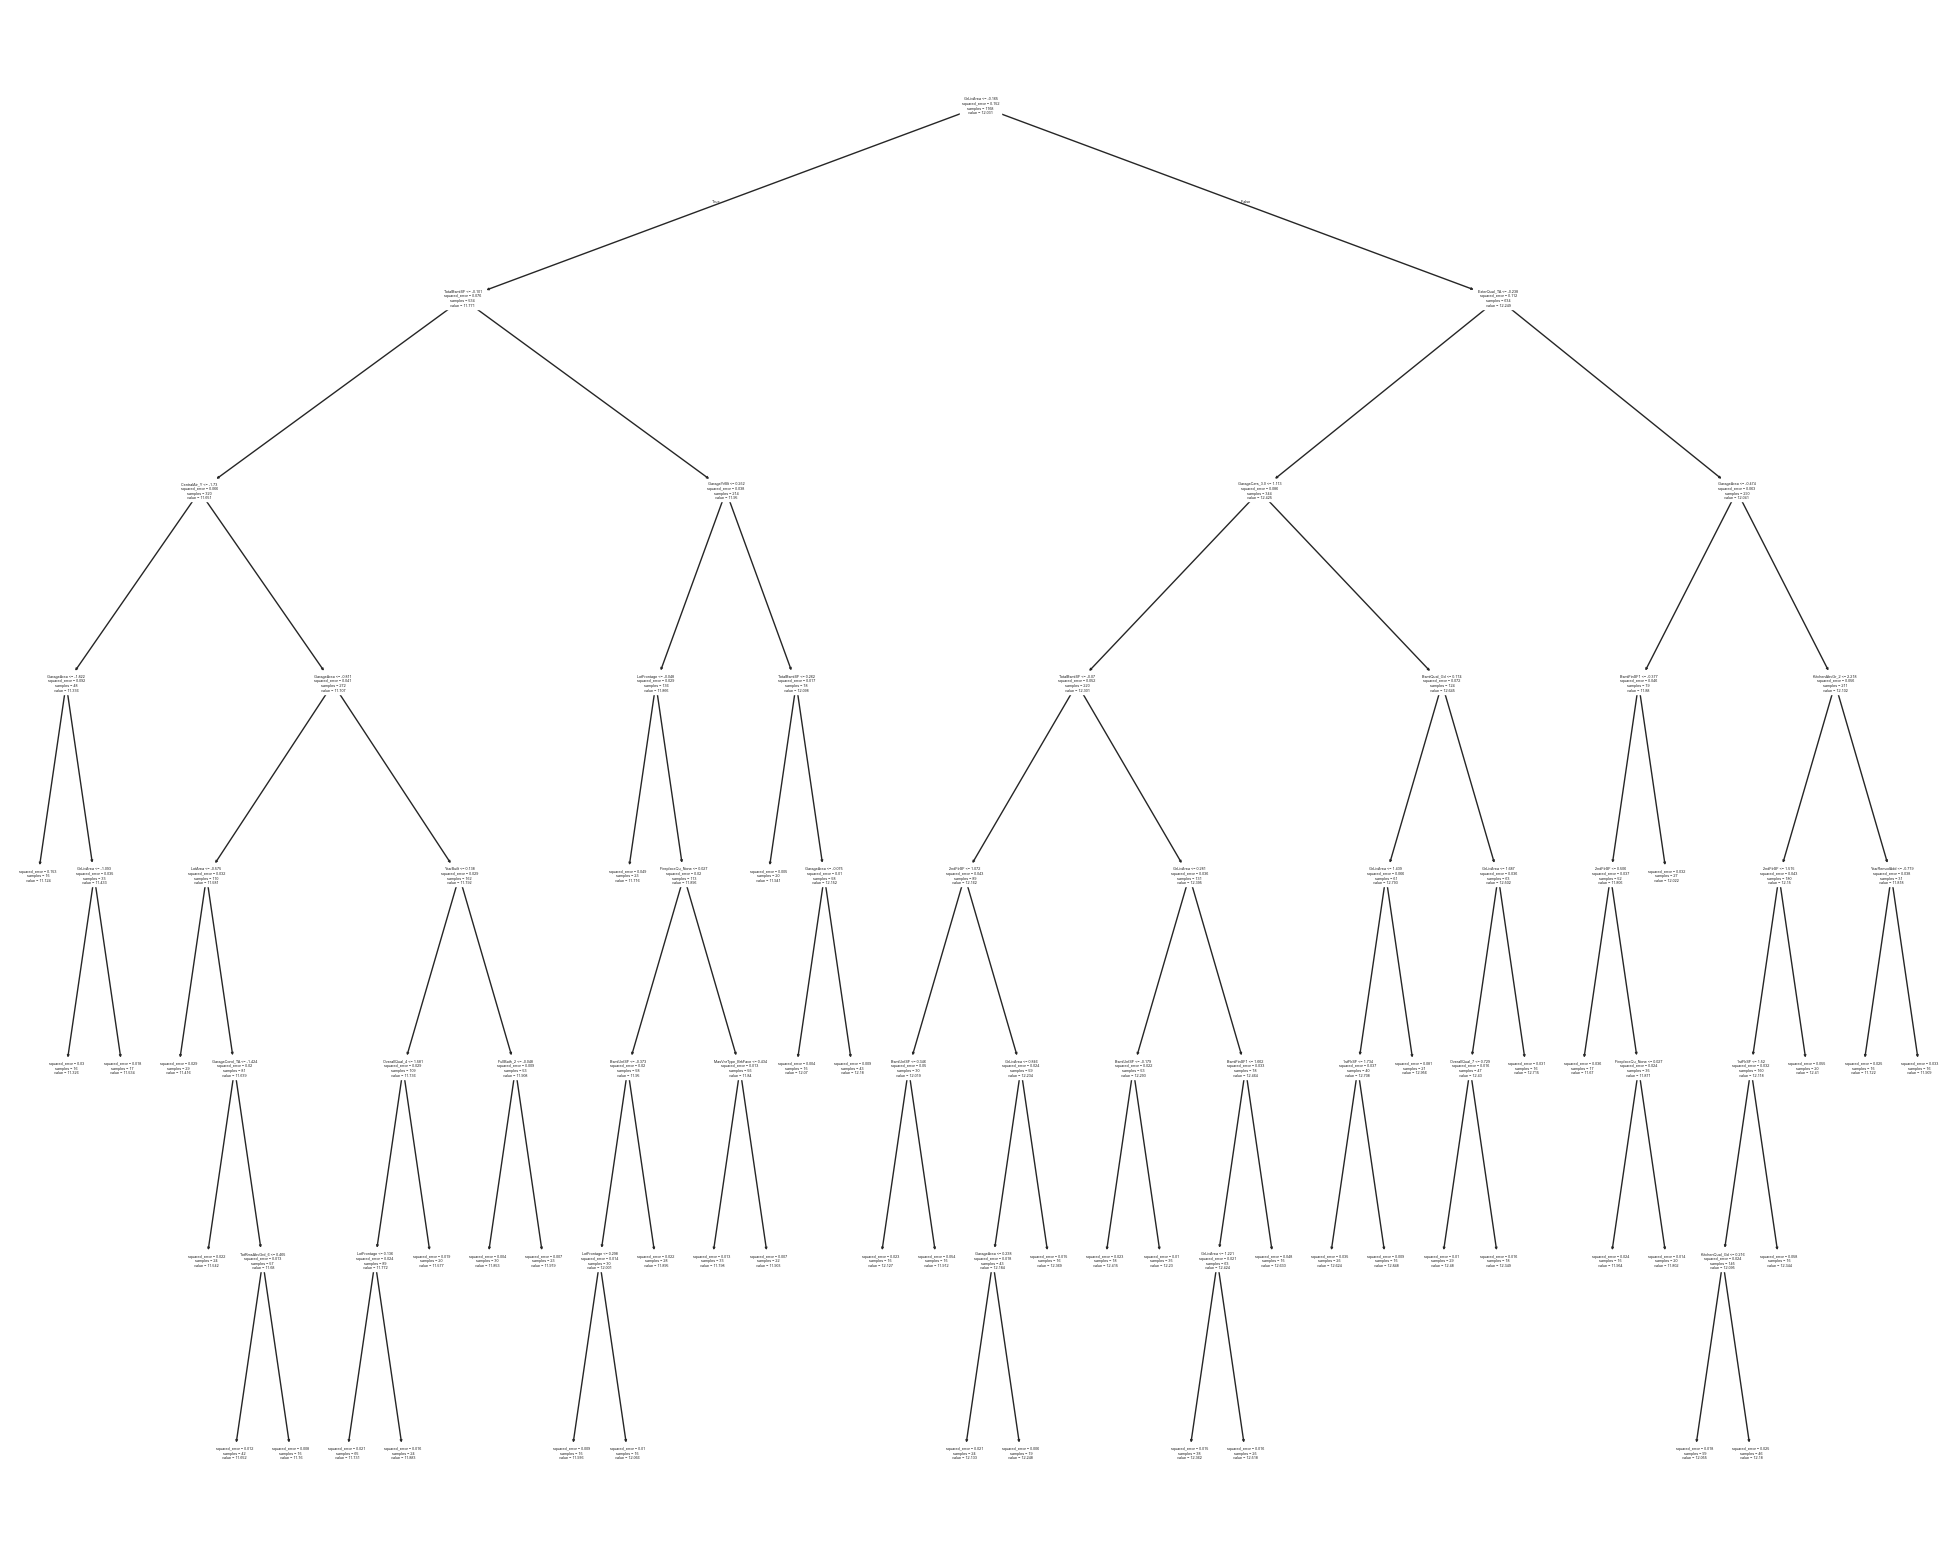

In [117]:
# plot the tree
from sklearn.tree import plot_tree
fig = plt.figure(figsize =(25,20))
plot_tree(tree_res, feature_names = X_train.columns)
plt.show()

In [118]:
pred_tree = tree_res.predict(X_valid)

In [119]:
abs_err_tree = abs(y_valid - pred_tree)

In [120]:
r2_tree = r2_score(y_valid,pred_tree)
RMSE_tree = np.sqrt(mean_squared_error(y_valid,pred_tree))

In [121]:
pred_tree_real = np.exp(pred_tree)
y_valid_real = np.exp(y_valid)
MAPE_tree = mean_absolute_percentage_error(y_valid_real,pred_tree_real)*100 

In [122]:
Decision_tree_row = pd.DataFrame({' r2':r2_tree,
                                   'RMSE':RMSE_tree,
                                   'MAPE':MAPE_tree,
                                   'Mean of AbsErrors':abs_err_tree.mean(),
                                   'Median of AbsErrors': abs_err_tree.median(),
                                   'SD of AbsErrors': abs_err_tree.std(),
                                   'IQR of AbsErrors': iqr(abs_err_tree),
                                   'Min of AbsErrors': abs_err_tree.min(),
                                   'Max of AbsErrors': abs_err_tree.max()},index =['Decission Tree'])
model_comp = pd.concat([model_comp, Decision_tree_row])
model_comp.round(3)

,r2,RMSE,MAPE,Mean of AbsErrors,Median of AbsErrors,SD of AbsErrors,IQR of AbsErrors,Min of AbsErrors,Max of AbsErrors
Linear Regression,0.818,0.185,9.180,0.095,0.059,0.158,0.098,0.0,2.279
Ridge Regression,0.875,0.153,10.388,0.098,0.059,0.117,0.099,0.0,0.928
lasso Regression,0.866,0.158,10.576,0.100,0.064,0.123,0.080,0.0,0.940
Decission Tree,0.789,0.198,14.806,0.139,0.091,0.141,0.150,0.0,0.938


C:\Users\AlMahdi\AppData\Local\Temp\ipykernel_6888\4050419175.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.1, 0.1, 0.1, 1)). The keyword argument will take precedence.
  plt.plot(xp,xp,'k',alpha=0.9, linewidth=2, color='red')


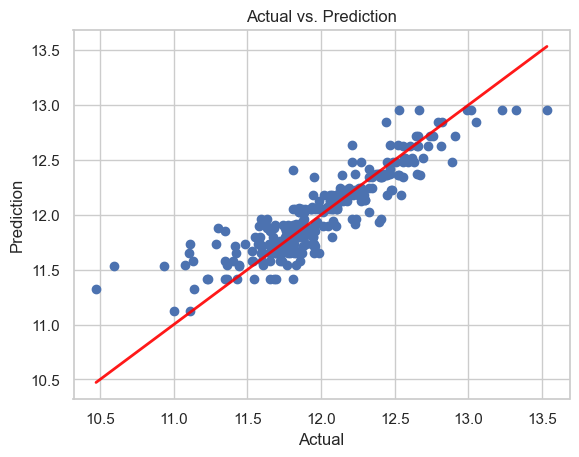

In [123]:
# Actual vs. Prediction
plt.scatter( x=y_valid, y=pred_tree )
plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs. Prediction')

#Add 45 degree line
xp = np.linspace(y_valid.min(), y_valid.max(),100)
plt.plot(xp,xp,'k',alpha=0.9, linewidth=2, color='red')

## Model 5: Bagging

In [124]:
from sklearn.ensemble import RandomForestRegressor

In [125]:
baggingreg = RandomForestRegressor(max_features= 79,random_state = 123, n_estimators =500)
bagging_reg = baggingreg.fit(X_train, y_train)

In [126]:
pred_bagging = bagging_reg.predict(X_valid)

In [127]:
abs_err_bagging = abs(y_valid - pred_bagging)     

In [128]:
r2_bagging = r2_score(y_valid,pred_bagging)
RMSE_bagging = np.sqrt(mean_squared_error(y_valid,pred_bagging))

In [129]:
pred_bagging_real = np.exp(pred_bagging)
y_valid_real = np.exp(y_valid)
MAPE_bagging = mean_absolute_percentage_error(y_valid_real,pred_bagging_real)*100 

In [130]:
Bagging_row = pd.DataFrame({' r2':r2_bagging,
                           'RMSE' :RMSE_bagging,
                            'MAPE' :MAPE_bagging,
                           'Mean of AbsErrors':abs_err_bagging.mean(),
                           'Median of AbsErrors': abs_err_bagging.median(),
                           'SD of AbsErrors': abs_err_bagging.std(),
                           'IQR of AbsErrors': iqr(abs_err_bagging),
                           'Min of AbsErrors': abs_err_bagging.min(),
                           'Max of AbsErrors': abs_err_bagging.max()},index =['Bagging'])
model_comp = pd.concat([model_comp, Bagging_row])
model_comp.round(3)

,r2,RMSE,MAPE,Mean of AbsErrors,Median of AbsErrors,SD of AbsErrors,IQR of AbsErrors,Min of AbsErrors,Max of AbsErrors
Linear Regression,0.818,0.185,9.180,0.095,0.059,0.158,0.098,0.0,2.279
Ridge Regression,0.875,0.153,10.388,0.098,0.059,0.117,0.099,0.0,0.928
lasso Regression,0.866,0.158,10.576,0.100,0.064,0.123,0.080,0.0,0.940
Decission Tree,0.789,0.198,14.806,0.139,0.091,0.141,0.150,0.0,0.938
Bagging,0.865,0.159,10.758,0.101,0.060,0.123,0.099,0.0,0.920


## Model 6: Random Forest

In [131]:
from sklearn.ensemble import RandomForestRegressor
rfreg = RandomForestRegressor(max_features = 26, random_state = 123, n_estimators = 500)
rf_reg = rfreg.fit(X_train , y_train)

In [132]:
Importance = pd.DataFrame({'Importance':rf_reg.feature_importances_*100}, index= X_train.columns)
Importance.sort_values(by = "Importance", axis=0, ascending=False)  # shows the importance of variables 

,Importance
GrLivArea,9.148526
YearBuilt,5.504568
GarageArea,5.000971
TotalBsmtSF,4.876086
ExterQual_TA,4.540167
1stFlrSF,4.438220
GarageYrBlt,4.075170
FullBath_1,3.269864
YearRemodAdd,3.136204
FireplaceQu_None,2.701169


In [133]:
# prediction
pred_rf = rf_reg.predict(X_valid)

In [134]:
abs_err_rf = abs(y_valid - pred_rf)                        

In [135]:
r2_rf = r2_score(y_valid,pred_rf)
RMSE_rf = np.sqrt(mean_squared_error(y_valid,pred_rf))

In [136]:
pred_rf_real = np.exp(pred_rf)
y_valid_real = np.exp(y_valid)
MAPE_rf = mean_absolute_percentage_error(y_valid_real,pred_rf_real)*100 

In [137]:
RandomForest_row = pd.DataFrame({' r2':r2_rf,
                           'RMSE' :RMSE_rf,
                           'MAPE' :MAPE_rf,
                           'Mean of AbsErrors':abs_err_rf.mean(),
                           'Median of AbsErrors': abs_err_rf.median(),
                           'SD of AbsErrors': abs_err_rf.std(),
                           'IQR of AbsErrors': iqr(abs_err_rf),
                           'Min of AbsErrors': abs_err_rf.min(),
                           'Max of AbsErrors': abs_err_rf.max()},index =['Random Forest'])
model_comp = pd.concat([model_comp,RandomForest_row])
model_comp.round(3)

,r2,RMSE,MAPE,Mean of AbsErrors,Median of AbsErrors,SD of AbsErrors,IQR of AbsErrors,Min of AbsErrors,Max of AbsErrors
Linear Regression,0.818,0.185,9.180,0.095,0.059,0.158,0.098,0.0,2.279
Ridge Regression,0.875,0.153,10.388,0.098,0.059,0.117,0.099,0.0,0.928
lasso Regression,0.866,0.158,10.576,0.100,0.064,0.123,0.080,0.0,0.940
Decission Tree,0.789,0.198,14.806,0.139,0.091,0.141,0.150,0.0,0.938
Bagging,0.865,0.159,10.758,0.101,0.060,0.123,0.099,0.0,0.920
Random Forest,0.857,0.164,10.994,0.103,0.064,0.127,0.091,0.0,0.977


## Model 7: Gradient Boosting Regression

In [138]:
from sklearn.ensemble import GradientBoostingRegressor

In [139]:
# k-Fold Cross Validation to choose Hyper-parameters
# Create Hyper-parameter grid
learning_rate = [0.01,0.1,0.3]
subsample=[0.6,0.8,1]
max_depth= [1,3,5]
grid = list(itertools.product(learning_rate, subsample, max_depth))
grid = pd.DataFrame(data= grid, index=range(1,28), columns=['learning_rate','subsample','max_depth'])

In [140]:
# k-fold Cross Validation to Choose the Best Model
cv_errors = np.zeros(shape=grid.shape[0])
for i in range(grid.shape[0]):
    boostingreg = GradientBoostingRegressor(learning_rate = grid.iloc[i,0],
                                            subsample = grid.iloc[i,1],
                                            max_depth = grid.iloc[i,2],
                                            min_samples_leaf = 5,
                                            n_estimators = 100)
    scores = cross_val_score(estimator = boostingreg, X = X_train, y = y_train, 
                             scoring='neg_root_mean_squared_error',
                             cv =5 , n_jobs = -1)
    cv_errors[i] = scores.mean()

In [141]:
cv_errors

array([-0.29368107, -0.2323358 , -0.21356166, -0.2950823 , -0.23354179,
       -0.21403597, -0.29655689, -0.23500882, -0.21592974, -0.15806222,
       -0.13660778, -0.134075  , -0.15888597, -0.13557803, -0.13639827,
       -0.1609856 , -0.13799501, -0.13701691, -0.15118955, -0.14934018,
       -0.15192625, -0.14869907, -0.14394057, -0.14689845, -0.14537483,
       -0.14156256, -0.14583104])

In [142]:
grid.iloc[np.argmax(cv_errors), :]

learning_rate    0.1
subsample        0.6
max_depth        5.0
Name: 12, dtype: float64

In [143]:
boosting_reg = GradientBoostingRegressor(learning_rate = 0.1,
                                            subsample = 0.6,
                                            max_depth = 5,
                                            min_samples_leaf = 5,
                                            n_estimators = 100,
                                            random_state = 1234)
boosting_res = boosting_reg.fit(X_train, y_train)

In [144]:
pred_boosting = boosting_res.predict(X_valid)

In [145]:
abs_err_boosting = abs(y_valid - pred_boosting)

In [146]:
r2_boosting = r2_score(y_valid,pred_boosting)
RMSE_boosting = np.sqrt(mean_squared_error(y_valid,pred_boosting))

In [147]:
pred_boosting_real = np.exp(pred_boosting)
y_valid_real = np.exp(y_valid)
MAPE_boosting = mean_absolute_percentage_error(y_valid_real,pred_boosting_real)*100 

In [148]:
GB_row = pd.DataFrame({' r2':r2_boosting,
                           'RMSE' :RMSE_boosting,
                           'MAPE' :MAPE_boosting,
                           'Mean of AbsErrors':abs_err_boosting.mean(),
                           'Median of AbsErrors': abs_err_boosting.median(),
                           'SD of AbsErrors': abs_err_boosting.std(),
                           'IQR of AbsErrors': iqr(abs_err_boosting),
                           'Min of AbsErrors': abs_err_boosting.min(),
                           'Max of AbsErrors': abs_err_boosting.max()},index =['Gradient Boosting'])
model_comp
model_comp = pd.concat([model_comp,GB_row])
model_comp.round(3)

,r2,RMSE,MAPE,Mean of AbsErrors,Median of AbsErrors,SD of AbsErrors,IQR of AbsErrors,Min of AbsErrors,Max of AbsErrors
Linear Regression,0.818,0.185,9.180,0.095,0.059,0.158,0.098,0.000,2.279
Ridge Regression,0.875,0.153,10.388,0.098,0.059,0.117,0.099,0.000,0.928
lasso Regression,0.866,0.158,10.576,0.100,0.064,0.123,0.080,0.000,0.940
Decission Tree,0.789,0.198,14.806,0.139,0.091,0.141,0.150,0.000,0.938
Bagging,0.865,0.159,10.758,0.101,0.060,0.123,0.099,0.000,0.920
Random Forest,0.857,0.164,10.994,0.103,0.064,0.127,0.091,0.000,0.977
Gradient Boosting,0.884,0.147,10.397,0.098,0.064,0.110,0.082,0.001,0.842


C:\Users\AlMahdi\AppData\Local\Temp\ipykernel_6888\3147274335.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.1, 0.1, 0.1, 1)). The keyword argument will take precedence.
  plt.plot(xp,xp,'k',alpha=0.9, linewidth=2, color='red')


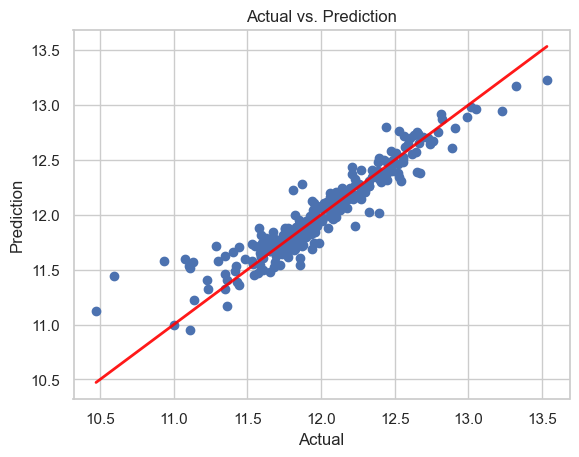

In [149]:
# Actual vs. Prediction
plt.scatter(x=y_valid, y=pred_boosting)
plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs. Prediction')

#Add 45 degree line
xp = np.linspace(y_valid.min(), y_valid.max(),100)
plt.plot(xp,xp,'k',alpha=0.9, linewidth=2, color='red')

### more tunning GradientBoost Regression

In [150]:
min_samples_leaf = [5,10,20]
max_depth = [4,5,6]
subsample = [0.7,0.8,0.9]
grid = list(itertools.product(min_samples_leaf, max_depth, subsample))
grid = pd.DataFrame(data= grid, index=range(1,28), columns=['min_samples_leaf','max_depth','subsample'])

In [151]:
# k-fold Cross Validation to Choose the Best Model
cv_errors = np.zeros(shape=grid.shape[0])
for i in range(grid.shape[0]):
    boostingreg = GradientBoostingRegressor(min_samples_leaf = grid.iloc[i,0],
                                            max_depth = grid.iloc[i,1],
                                            subsample = grid.iloc[i,2],
                                            learning_rate = 0.1,
                                            n_estimators = 100)
    scores = cross_val_score(estimator = boostingreg, X = X_train, y = y_train, 
                             scoring='neg_root_mean_squared_error',
                             cv =5 , n_jobs = -1)
    cv_errors[i] = scores.mean()

In [152]:
cv_errors

array([-0.13414841, -0.13495006, -0.13650956, -0.13449993, -0.13380854,
       -0.13630911, -0.13576096, -0.13942874, -0.13718501, -0.132101  ,
       -0.13453028, -0.13508221, -0.13434682, -0.13344583, -0.13583478,
       -0.13480013, -0.13435604, -0.13623391, -0.13564122, -0.1372295 ,
       -0.13652554, -0.13508845, -0.13611118, -0.13709387, -0.13612761,
       -0.13627496, -0.13755101])

In [153]:
grid.iloc[np.argmax(cv_errors), :]

min_samples_leaf    10.0
max_depth            4.0
subsample            0.7
Name: 10, dtype: float64

In [154]:
boosting_reg = GradientBoostingRegressor(learning_rate = 0.1,
                                            subsample = 0.7,
                                            max_depth = 4,
                                            min_samples_leaf = 10,
                                            n_estimators = 100,
                                            random_state = 1234)
boosting_res = boosting_reg.fit(X_train, y_train)

In [155]:
pred_Tuneboosting = boosting_res.predict(X_valid)

In [156]:
abs_err_Tuneboosting = abs(y_valid - pred_Tuneboosting)

In [157]:
r2_Tuneboosting = r2_score(y_valid,pred_Tuneboosting)
RMSE_Tuneboosting = np.sqrt(mean_squared_error(y_valid,pred_Tuneboosting))

In [158]:
pred_Tuneboosting_real = np.exp(pred_Tuneboosting)
y_valid_real = np.exp(y_valid)
MAPE_Tuneboosting = mean_absolute_percentage_error(y_valid_real,pred_Tuneboosting_real)*100

In [159]:
GB_tuned_row = pd.DataFrame({' r2':r2_Tuneboosting,
                           'RMSE' :RMSE_Tuneboosting,
                           'MAPE' :MAPE_Tuneboosting,
                           'Mean of AbsErrors':abs_err_Tuneboosting.mean(),
                           'Median of AbsErrors': abs_err_Tuneboosting.median(),
                           'SD of AbsErrors': abs_err_Tuneboosting.std(),
                           'IQR of AbsErrors': iqr(abs_err_Tuneboosting),
                           'Min of AbsErrors': abs_err_Tuneboosting.min(),
                           'Max of AbsErrors': abs_err_Tuneboosting.max()},index =['Tuned GradientBoosting'])
model_comp = pd.concat([model_comp,GB_tuned_row])
model_comp.round(3)

,r2,RMSE,MAPE,Mean of AbsErrors,Median of AbsErrors,SD of AbsErrors,IQR of AbsErrors,Min of AbsErrors,Max of AbsErrors
Linear Regression,0.818,0.185,9.180,0.095,0.059,0.158,0.098,0.000,2.279
Ridge Regression,0.875,0.153,10.388,0.098,0.059,0.117,0.099,0.000,0.928
lasso Regression,0.866,0.158,10.576,0.100,0.064,0.123,0.080,0.000,0.940
Decission Tree,0.789,0.198,14.806,0.139,0.091,0.141,0.150,0.000,0.938
Bagging,0.865,0.159,10.758,0.101,0.060,0.123,0.099,0.000,0.920
Random Forest,0.857,0.164,10.994,0.103,0.064,0.127,0.091,0.000,0.977
Gradient Boosting,0.884,0.147,10.397,0.098,0.064,0.110,0.082,0.001,0.842
Tuned GradientBoosting,0.892,0.142,10.159,0.096,0.070,0.105,0.087,0.002,0.779


C:\Users\AlMahdi\AppData\Local\Temp\ipykernel_6888\3147274335.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.1, 0.1, 0.1, 1)). The keyword argument will take precedence.
  plt.plot(xp,xp,'k',alpha=0.9, linewidth=2, color='red')


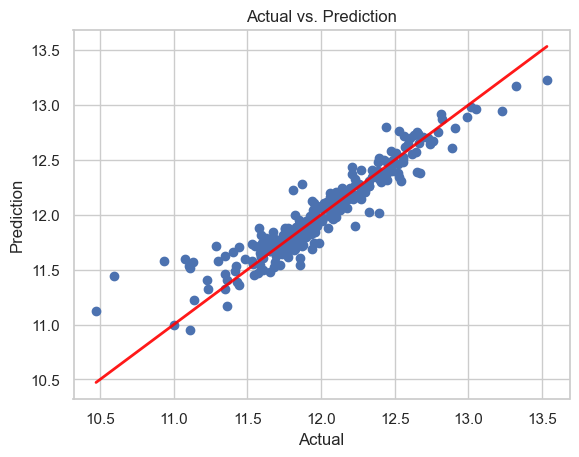

In [160]:
# Actual vs. Prediction
plt.scatter(x=y_valid, y=pred_boosting)
plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs. Prediction')

#Add 45 degree line
xp = np.linspace(y_valid.min(), y_valid.max(),100)
plt.plot(xp,xp,'k',alpha=0.9, linewidth=2, color='red')

## Model 8: Extreme Gradient Boost:

In [161]:
from xgboost import XGBRegressor

In [162]:
# k_fold Cross Validation to choose Hyper-parameters
# Create Hyper-parameters grid

learning_rate =[0.01, 0.05, 0.1, 0.3]
max_depth = [1,3,5,7]
subsample = [0.6, 0.8, 1]
colsample_bytree = [0.8, 0.9, 1]
grid = list(itertools.product(learning_rate, max_depth, subsample, colsample_bytree))
grid = pd.DataFrame(data =grid, index= range(1,145), columns = ['learning_rate','max_depth','subsample','colsample_bytree'])

In [163]:
# k-fold Cross Validation to choose the Best Model
cv_errors = np.zeros(shape = grid.shape[0])

for i in range(grid.shape[0]):
    xgbreg = XGBRegressor(n_estimators =1000, learning_rate= grid.iloc[i,0],max_depth=grid.iloc[i,1],
                          subsample=grid.iloc[i,2], colsample_bytree = grid.iloc[i,3], reg_alpha=0.1,
                          reg_lambda= 0.1, n_jobs= -1, random_state =1234)
    scores = cross_val_score(estimator = xgbreg, X= X_train , y=y_train, scoring='neg_root_mean_squared_error',cv=5, n_jobs= -1)
    cv_errors[i] = scores.mean()

In [164]:
cv_errors

array([-0.1584199 , -0.15851021, -0.15823193, -0.15980987, -0.15974924,
       -0.15975497, -0.16240527, -0.16238775, -0.16234844, -0.13289973,
       -0.13290594, -0.13294884, -0.13309029, -0.13340512, -0.13363192,
       -0.1354855 , -0.13543373, -0.13501046, -0.13018366, -0.13137667,
       -0.13098884, -0.13232489, -0.13296831, -0.13409552, -0.13489545,
       -0.13594732, -0.13632863, -0.13390226, -0.13441461, -0.13508728,
       -0.13779196, -0.13873551, -0.13908954, -0.14430551, -0.14606468,
       -0.14785186, -0.13618563, -0.13628204, -0.13697937, -0.1369574 ,
       -0.13741156, -0.13707693, -0.13769539, -0.13732013, -0.13750658,
       -0.12667791, -0.12908976, -0.12963339, -0.12966764, -0.13006809,
       -0.12915989, -0.1297457 , -0.12978334, -0.12936546, -0.131706  ,
       -0.13299426, -0.13152609, -0.13280092, -0.13403808, -0.13377488,
       -0.13469696, -0.13583368, -0.13641979, -0.13709056, -0.13801493,
       -0.13728789, -0.13886655, -0.14053825, -0.13948027, -0.14

In [165]:
grid.iloc[np.argmax(cv_errors),:]

learning_rate       0.05
max_depth           3.00
subsample           0.60
colsample_bytree    0.80
Name: 46, dtype: float64

In [166]:
xgbreg = XGBRegressor(n_estimators=1000, max_depth=3  , learning_rate= 0.05 , subsample= 0.6 , colsample_bytree= 0.8 , 
                       reg_alpha = 0.1 , reg_lambda= 0.1 , n_jobs=-1, random_state=1234)
xgb_reg = xgbreg.fit(X_train , y_train)

In [167]:
pred_xgb = xgb_reg.predict(X_valid)

In [168]:
abs_err_xgb = abs(y_valid - pred_xgb)

In [169]:
r2_xgb = r2_score(y_valid,pred_xgb)
RMSE_xgb = np.sqrt(mean_squared_error(y_valid,pred_xgb))

In [170]:
pred_xgb_real = np.exp(pred_xgb)
y_valid_real = np.exp(y_valid)
MAPE_xgb = mean_absolute_percentage_error(y_valid_real,pred_xgb_real)*100 

In [171]:
XGB_row = pd.DataFrame({' r2':r2_xgb,
                           'RMSE' :RMSE_xgb,
                           'MAPE' :MAPE_xgb,
                           'Mean of AbsErrors':abs_err_xgb.mean(),
                           'Median of AbsErrors': abs_err_xgb.median(),
                           'SD of AbsErrors': abs_err_xgb.std(),
                           'IQR of AbsErrors': iqr(abs_err_xgb),
                           'Min of AbsErrors': abs_err_xgb.min(),
                           'Max of AbsErrors': abs_err_xgb.max()},index =['XGBoost'])
model_comp = pd.concat([model_comp, XGB_row])
model_comp.round(3)

,r2,RMSE,MAPE,Mean of AbsErrors,Median of AbsErrors,SD of AbsErrors,IQR of AbsErrors,Min of AbsErrors,Max of AbsErrors
Linear Regression,0.818,0.185,9.180,0.095,0.059,0.158,0.098,0.000,2.279
Ridge Regression,0.875,0.153,10.388,0.098,0.059,0.117,0.099,0.000,0.928
lasso Regression,0.866,0.158,10.576,0.100,0.064,0.123,0.080,0.000,0.940
Decission Tree,0.789,0.198,14.806,0.139,0.091,0.141,0.150,0.000,0.938
Bagging,0.865,0.159,10.758,0.101,0.060,0.123,0.099,0.000,0.920
Random Forest,0.857,0.164,10.994,0.103,0.064,0.127,0.091,0.000,0.977
Gradient Boosting,0.884,0.147,10.397,0.098,0.064,0.110,0.082,0.001,0.842
Tuned GradientBoosting,0.892,0.142,10.159,0.096,0.070,0.105,0.087,0.002,0.779
XGBoost,0.894,0.141,9.607,0.092,0.057,0.107,0.088,0.000,0.901


C:\Users\AlMahdi\AppData\Local\Temp\ipykernel_6888\3975044010.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.1, 0.1, 0.1, 1)). The keyword argument will take precedence.
  plt.plot(xp,xp,'k',alpha=0.9, linewidth=2, color='red')


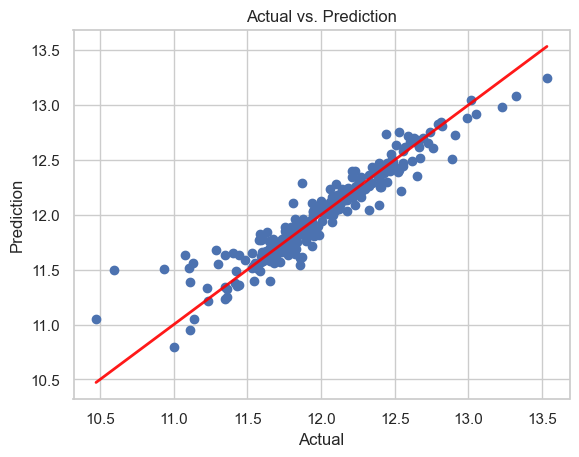

In [172]:
# Actual vs. Prediction
plt.scatter(x=y_valid, y=pred_xgb)
plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs. Prediction')

#Add 45 degree line
xp = np.linspace(y_valid.min(), y_valid.max(),100)
plt.plot(xp,xp,'k',alpha=0.9, linewidth=2, color='red')

In [173]:
# According to the above table, based on r2, RMSE and Mean of Absolute Errors, we can choose XtremeGradientBoost as the best model and
# apply it to test dataSet to obtain final results. 

In [174]:
xgbreg = XGBRegressor(n_estimators=1000, max_depth=3  , learning_rate= 0.05 , subsample= 0.6 , colsample_bytree= 0.8 , 
                       reg_alpha = 0.1 , reg_lambda= 0.1 , n_jobs=-1, random_state=1234)
xgb_reg = xgbreg.fit(train_l , log_y)   

In [175]:
test_l = df_scaled[len(log_y):]

In [176]:
test_l.shape

(1459, 322)

In [177]:
pred_test_log = xgb_reg.predict(test_l)

In [178]:
pred_test = np.exp(pred_test_log)

In [179]:
# saving of final SalePrice as a DataFrame

In [180]:
submission = pd.DataFrame({'Id': test['Id'],
                           'SalePrice' : pred_test})